In [2]:
!pip install langchain langchain_core langchain_groq langchain_community langchain langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 557.4/557.4 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-protocol
    Found existing installation: langchain-protocol 0.0.16
    Uninstalling langchain-protocol-0.0.16:
      Successfully uninstalled langchain-protocol-0.0.16
  Attempting uninstall: langchain_core
    Found existing installation: langchain-core 1.4.3
    Uninstalling langchain-core-1.4.3:
      Successfully uninstalled langchain-core-1.4.3
ERROR: pip's dependency resolver does not currently take

In [3]:
import os
from typing import TypedDict, Annotated, List
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage, AIMessage
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables.graph import MermaidDrawMethod
from IPython.display import display, Image

In [4]:

from typing import TypedDict, List
from langchain_core.messages import BaseMessage

class PlannerState(TypedDict):
    messages: List[BaseMessage]

    budget: int | None
    adults: int | None
    children: int | None
    days: int | None

    preferences: List[str]
    destination: str | None

    hotel_type: str | None
    food_preferences: List[str]

    budget_status: str | None
    input_valid: bool

    cost_breakdown: dict
    itinerary: str

    regenerate: bool

In [ ]:
from langchain_groq import ChatGroq
import os
llm = ChatGroq(
    temperature = 0,
    groq_api_key = os.environ["GROQ_API_KEY"],
    model_name = "llama-3.3-70b-versatile"
)

In [6]:
from langchain_core.prompts import ChatPromptTemplate

itinerary_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are an expert AI Travel Planner.

        Create a realistic, budget-aware travel itinerary.

        Use the user's:
        - Budget
        - Number of adults
        - Number of children
        - Trip duration
        - Sightseeing preferences
        - Destination
        - Hotel preferences
        - Food preferences

        Requirements:
        - Stay within budget
        - Create a day-by-day itinerary
        - Include morning, afternoon, and evening activities
        - Recommend hotels
        - Recommend restaurants
        - Suggest transportation options
        - Include estimated costs
        - Explain why the destination matches the user's preferences

        Return the itinerary in a well-structured format.
        """
    ),
    (
        "human",
        """
        Trip Details

        Budget: ₹{budget}

        Adults: {adults}

        Children: {children}

        Number of Days: {days}

        Destination: {destination}

        Sightseeing Preferences:
        {preferences}

        Hotel Type:
        {hotel_type}

        Food Preferences:
        {food_preferences}

        Cost Breakdown:
        {cost_breakdown}

        Create a complete travel plan.
        """
    ),
])


In [7]:
def generate_itinerary(state: PlannerState):

    prompt = itinerary_prompt.invoke({
        "budget": state["budget"],
        "adults": state["adults"],
        "children": state["children"],
        "days": state["days"],
        "destination": state["destination"],
        "preferences": ", ".join(state["preferences"]),
        "hotel_type": state["hotel_type"],
        "food_preferences": ", ".join(state["food_preferences"]),
        "cost_breakdown": state["cost_breakdown"]
    })

    response = llm.invoke(prompt)

    return {
        **state,
        "itinerary": response.content
    }


In [8]:

from langchain_core.messages import HumanMessage, AIMessage

def input_budget(state: PlannerState) -> PlannerState:
    print("Enter your total trip budget (INR):")
    user_message = input("Your Input: ")

    return {
        **state,
        "budget": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Budget: {user_message}")
        ]
    }


def input_adults(state: PlannerState) -> PlannerState:
    print("Enter the number of adults:")
    user_message = input("Your Input: ")

    return {
        **state,
        "adults": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Adults: {user_message}")
        ]
    }


def input_children(state: PlannerState) -> PlannerState:
    print("Enter the number of children:")
    user_message = input("Your Input: ")

    return {
        **state,
        "children": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Children: {user_message}")
        ]
    }


def input_days(state: PlannerState) -> PlannerState:
    print("Enter the number of travel days:")
    user_message = input("Your Input: ")

    return {
        **state,
        "days": int(user_message),
        "messages": state["messages"] + [
            HumanMessage(content=f"Days: {user_message}")
        ]
    }


def input_preferences(state: PlannerState) -> PlannerState:
    print(
        "Enter sightseeing preferences "
        "(Nature, Beaches, Temples, Adventure, Shopping, Heritage):"
    )

    user_message = input("Your Input: ")

    return {
        **state,
        "preferences": [
            p.strip()
            for p in user_message.split(",")
        ],
        "messages": state["messages"] + [
            HumanMessage(content=f"Preferences: {user_message}")
        ]
    }


def input_destination(state: PlannerState) -> PlannerState:
    print(
        "Enter destination (optional, press Enter for recommendations):"
    )

    user_message = input("Your Input: ")

    return {
        **state,
        "destination": user_message if user_message else None,
        "messages": state["messages"] + [
            HumanMessage(content=f"Destination: {user_message}")
        ]
    }


def create_itinerary(state: PlannerState) -> PlannerState:

    print("\nGenerating travel itinerary...\n")

    response = llm.invoke(
        itinerary_prompt.format_messages(
            budget=state["budget"],
            adults=state["adults"],
            children=state["children"],
            days=state["days"],
            destination=state["destination"] or "Suggest a destination",
            preferences=", ".join(state["preferences"]),
            hotel_type=state.get("hotel_type", "Standard"),
            food_preferences=", ".join(
                state.get("food_preferences", [])
            ),
            cost_breakdown=state.get("cost_breakdown", {})
        )
    )

    print("\n===== FINAL ITINERARY =====\n")
    print(response.content)

    return {
        **state,
        "itinerary": response.content,
        "messages": state["messages"] + [
            AIMessage(content=response.content)
        ]
    }



In [9]:

from langchain_core.messages import HumanMessage, AIMessage

# =====================================
# S1 - Collect Required Inputs
# =====================================

def collect_required_inputs(state: PlannerState) -> PlannerState:

    print("\n=== Travel Planner ===")

    budget = int(input("Budget (INR): "))
    adults = int(input("Adults: "))
    children = int(input("Children: "))
    days = int(input("Days: "))

    preferences = input(
        "Preferences (Nature, Beaches, Adventure, Shopping): "
    )

    return {
        **state,
        "budget": budget,
        "adults": adults,
        "children": children,
        "days": days,
        "preferences": [
            p.strip()
            for p in preferences.split(",")
        ]
    }


# =====================================
# S2 - Validate Inputs
# =====================================

def validate_inputs(state: PlannerState) -> PlannerState:

    valid = True

    if state["budget"] <= 0:
        valid = False

    if state["days"] <= 0:
        valid = False

    if state["adults"] < 0:
        valid = False

    if state["children"] < 0:
        valid = False

    return {
        **state,
        "input_valid": valid
    }


# =====================================
# S3 - Check Destination
# =====================================

def check_destination(state: PlannerState) -> PlannerState:

    destination = input(
        "Destination (leave blank for suggestions): "
    )

    return {
        **state,
        "destination": destination
    }


# =====================================
# S3b - Suggest Destination
# =====================================

def suggest_destinations(state: PlannerState) -> PlannerState:

    suggestions = [
        "Munnar",
        "Wayanad",
        "Coorg"
    ]

    print("\nSuggested Destinations:")

    for i, place in enumerate(suggestions, 1):
        print(f"{i}. {place}")

    choice = int(input("Choose destination number: "))

    return {
        **state,
        "destination": suggestions[choice - 1]
    }


# =====================================
# S4 - Optional Inputs
# =====================================

def collect_optional_inputs(state: PlannerState) -> PlannerState:

    hotel_type = input(
        "Hotel Type (Budget / Standard / Luxury): "
    )

    food_preferences = input(
        "Food Preferences: "
    )

    mobility_constraints = input(
        "Mobility Constraints: "
    )

    must_visit_places = input(
        "Must Visit Places (comma separated): "
    )

    return {
        **state,
        "hotel_type": hotel_type,
        "food_preferences": [
            x.strip()
            for x in food_preferences.split(",")
        ],
        "mobility_constraints": mobility_constraints,
        "must_visit_places": [
            x.strip()
            for x in must_visit_places.split(",")
        ]
    }


# =====================================
# S5 - Budget Allocation
# =====================================

def budget_allocator(state: PlannerState) -> PlannerState:

    budget = state["budget"]

    breakdown = {
        "accommodation": budget * 0.35,
        "food": budget * 0.25,
        "transport": budget * 0.15,
        "attractions": budget * 0.10,
        "buffer": budget * 0.15,
    }

    return {
        **state,
        "cost_breakdown": breakdown
    }


# =====================================
# S6 - Budget Feasibility
# =====================================

def budget_feasibility(state: PlannerState) -> PlannerState:

    return {
        **state,
        "budget_status": "feasible"
    }


# =====================================
# S7 - Fetch Places
# =====================================

def fetch_places(state: PlannerState) -> PlannerState:

    return {
        **state,
        "api_available": True
    }


# =====================================
# S8 - Hotels
# =====================================

from langchain_core.prompts import ChatPromptTemplate

hotel_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are a travel expert. Recommend exactly 3 real hotels for the given destination.

        Rules:
        - Match the hotel type (Budget / Standard / Luxury)
        - Stay within the accommodation budget
        - Return ONLY a JSON list with this structure:

        [
          {{
            "name": "Hotel Name",
            "type": "Budget/Standard/Luxury",
            "price_per_night": 1500,
            "highlights": "Key features in one line",
            "address": "Area, City"
          }}
        ]

        Return nothing else. No explanation. Just the JSON list.
        """
    ),
    (
        "human",
        """
        Destination: {destination}
        Hotel Type: {hotel_type}
        Accommodation Budget: ₹{accommodation_budget}
        Number of Days: {days}
        """
    )
])

hotel_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """
        You are a travel expert. Recommend exactly 3 real hotels for the given destination.

        Rules:
        - Match the hotel type (Budget / Standard / Luxury)
        - Stay within the accommodation budget
        - Return ONLY a JSON list with this structure:

        [
          {{
            "name": "Hotel Name",
            "type": "Budget/Standard/Luxury",
            "price_per_night": 1500,
            "highlights": "Key features in one line",
            "address": "Area, City"
          }}
        ]

        Return nothing else. No explanation. Just the JSON list.
        """
    ),
    (
        "human",
        """
        Destination: {destination}
        Hotel Type: {hotel_type}
        Accommodation Budget: ₹{accommodation_budget}
        Number of Days: {days}
        """
    )
])

def select_hotels(state: PlannerState) -> PlannerState:

    accommodation_budget = state.get("cost_breakdown", {}).get("accommodation", 5000)

    prompt = hotel_prompt.invoke({
        "destination": state["destination"],
        "hotel_type": state["hotel_type"],
        "accommodation_budget": accommodation_budget,
        "days": state["days"]
    })

    response = llm.invoke(prompt)

    import json, re

    raw = response.content.strip()
    raw = re.sub(r"```json|```", "", raw).strip()

    try:
        hotels = json.loads(raw)
    except json.JSONDecodeError:
        hotels = [{"name": raw, "type": state["hotel_type"], "price_per_night": "N/A", "highlights": "", "address": ""}]

    print("\n Recommended Hotels:")
    print("=" * 40)
    for i, hotel in enumerate(hotels, 1):
        print(f"\n{i}. {hotel['name']}")
        print(f"   Type     : {hotel['type']}")
        print(f"   Price    : ₹{hotel['price_per_night']} / night")
        print(f"   Address  : {hotel['address']}")
        print(f"   Highlights: {hotel['highlights']}")
    print("=" * 40)

    return {
        **state,
        "hotels": hotels
    }

    response = llm.invoke(prompt)

    import json, re

    raw = response.content.strip()

    # Strip markdown code fences if present
    raw = re.sub(r"```json|```", "", raw).strip()

    try:
        hotels = json.loads(raw)
    except json.JSONDecodeError:
        hotels = [{"name": raw, "type": state["hotel_type"], "price_per_night": "N/A", "highlights": "", "address": ""}]

    return {
        **state,
        "hotels": hotels
    }

# =====================================
# S9 - Restaurants
# =====================================

def select_restaurants(state: PlannerState) -> PlannerState:

    prompt = f"""
    Suggest 3 restaurants in {state['destination']}.

    Return ONLY valid JSON.

    Format:

    [
      {{
        "name": "",
        "location": "",
        "cost_for_two": "",
        "cuisine": "",
        "rating": "",
        "group_note": ""
      }}
    ]

    Requirements:
    - Exactly 3 restaurants
    - Include approximate cost for two
    - Include cuisine type
    - Include rating out of 5
    - Include family/group suitability note
    """

    response = llm.invoke(prompt)

    import json
    import re

    raw = response.content.strip()

    # Remove markdown code blocks if present
    raw = re.sub(r"```json", "", raw)
    raw = re.sub(r"```", "", raw)

    try:
        restaurants = json.loads(raw)

    except json.JSONDecodeError:

        restaurants = [
            {
                "name": raw,
                "location": "N/A",
                "cost_for_two": "N/A",
                "cuisine": "N/A",
                "rating": "N/A",
                "group_note": "N/A"
            }
        ]

    print("\nRecommended Restaurants:")
    print("=" * 50)

    for i, restaurant in enumerate(restaurants, 1):

        print(f"\n{i}. {restaurant['name']}")
        print(f"   Location      : {restaurant['location']}")
        print(f"   Cost For Two  : ₹{restaurant['cost_for_two']}")
        print(f"   Cuisine       : {restaurant['cuisine']}")
        print(f"   Rating        : ⭐ {restaurant['rating']}")
        print(f"   Group Note    : {restaurant['group_note']}")

    print("=" * 50)

    return {
        **state,
        "restaurants": restaurants
    }

# =====================================
# S10 - Attractions
# =====================================

def select_attractions(state: PlannerState) -> PlannerState:

    attractions = [
        "Tea Gardens",
        "Waterfalls",
        "View Point"
    ]

    return {
        **state,
        "attractions": attractions,
        "trip_too_short": False
    }


# =====================================
# S11 - Assemble Itinerary
# =====================================

def assemble_itinerary(state: PlannerState) -> PlannerState:

    response = llm.invoke(
        itinerary_prompt.format_messages(
            budget=state["budget"],
            adults=state["adults"],
            children=state["children"],
            days=state["days"],
            destination=state["destination"],
            preferences=", ".join(
                state["preferences"]
            ),
            hotel_type=state["hotel_type"],
            food_preferences=", ".join(
                state["food_preferences"]
            ),
            cost_breakdown=state["cost_breakdown"]
        )
    )

    return {
        **state,
        "itinerary": response.content
    }


# =====================================
# S12 - Build Output
# =====================================

def build_output(state: PlannerState) -> PlannerState:

    return state


# =====================================
# S13 - Present Plan
# =====================================

def present_plan(state: PlannerState) -> PlannerState:

    print("\n========== FINAL PLAN ==========\n")

    print(state["itinerary"])

    return {
        **state,
        "regenerate": False
    }



In [10]:
from langgraph.graph import StateGraph, END

# Create workflow
workflow = StateGraph(PlannerState)

# =========================
# Add Nodes
# =========================

workflow.add_node(
    "collect_required_inputs",
    collect_required_inputs
)

workflow.add_node(
    "validate_inputs",
    validate_inputs
)

workflow.add_node(
    "check_destination",
    check_destination
)

workflow.add_node(
    "suggest_destinations",
    suggest_destinations
)

workflow.add_node(
    "collect_optional_inputs",
    collect_optional_inputs
)

workflow.add_node(
    "budget_allocator",
    budget_allocator
)

workflow.add_node(
    "budget_feasibility",
    budget_feasibility
)

workflow.add_node(
    "fetch_places",
    fetch_places
)

workflow.add_node(
    "select_hotels",
    select_hotels
)

workflow.add_node(
    "select_restaurants",
    select_restaurants
)

workflow.add_node(
    "select_attractions",
    select_attractions
)

workflow.add_node(
    "assemble_itinerary",
    assemble_itinerary
)

workflow.add_node(
    "build_output",
    build_output
)

workflow.add_node(
    "present_plan",
    present_plan
)

# =========================
# Entry Point
# =========================

workflow.set_entry_point(
    "collect_required_inputs"
)

# =========================
# Main Flow
# =========================

workflow.add_edge(
    "collect_required_inputs",
    "validate_inputs"
)

workflow.add_edge(
    "validate_inputs",
    "check_destination"
)

# =========================
# Conditional Routing
# =========================

def destination_router(state: PlannerState):

    if state["destination"].strip() == "":
        return "suggest"

    return "continue"


workflow.add_conditional_edges(
    "check_destination",
    destination_router,
    {
        "suggest": "suggest_destinations",
        "continue": "collect_optional_inputs"
    }
)

workflow.add_edge(
    "suggest_destinations",
    "collect_optional_inputs"
)

workflow.add_edge(
    "collect_optional_inputs",
    "budget_allocator"
)

workflow.add_edge(
    "budget_allocator",
    "budget_feasibility"
)

workflow.add_edge(
    "budget_feasibility",
    "fetch_places"
)

workflow.add_edge(
    "fetch_places",
    "select_hotels"
)

workflow.add_edge(
    "select_hotels",
    "select_restaurants"
)

workflow.add_edge(
    "select_restaurants",
    "select_attractions"
)

workflow.add_edge(
    "select_attractions",
    "assemble_itinerary"
)

workflow.add_edge(
    "assemble_itinerary",
    "build_output"
)

workflow.add_edge(
    "build_output",
    "present_plan"
)

workflow.add_edge(
    "present_plan",
    END
)

# =========================
# Compile Graph
# =========================

app = workflow.compile()

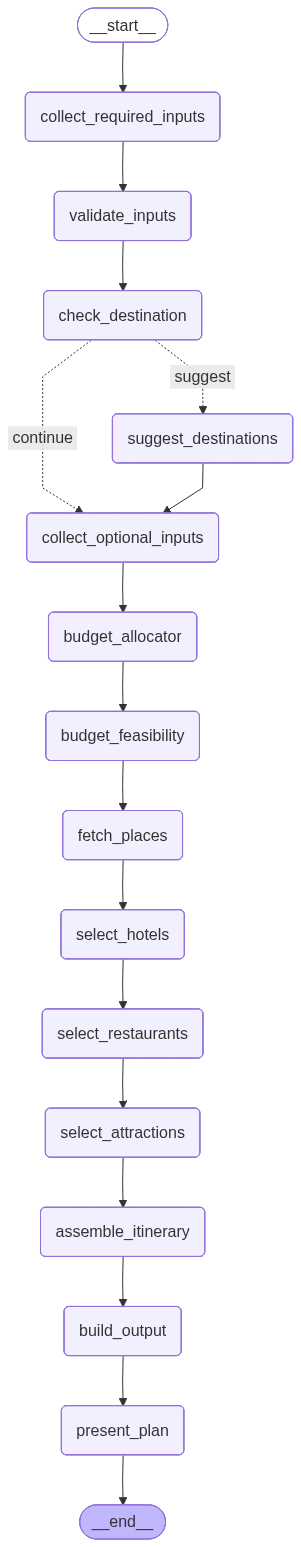

In [11]:
display(
    Image(
        app.get_graph().draw_mermaid_png(
            draw_method = MermaidDrawMethod.API
        )
    )
)

In [12]:
from langchain_core.messages import HumanMessage

def travel_planner(user_request: str):

    print(f"Initial Request: {user_request}\n")

    state = {
        "messages": [
            HumanMessage(content=user_request)
        ],

        # Required Inputs
        "budget": None,
        "adults": None,
        "children": None,
        "days": None,
        "preferences": [],
        "destination": None,

        # Optional Inputs
        "hotel_type": None,
        "food_preferences": [],
        "mobility_constraints": None,
        "must_visit_places": [],

        # Validation
        "input_valid": False,

        # Budget
        "budget_status": None,
        "cost_breakdown": {},

        # Recommendations
        "hotels": [],
        "restaurants": [],
        "attractions": [],
        "suggested_destinations": [],

        # Flags
        "trip_too_short": False,
        "regenerate": False,

        # Final Output
        "itinerary": ""
    }

    final_output = None

    for output in app.stream(state):
        final_output = output

    return final_output



In [13]:
result = travel_planner(
    """
    Budget: 80000 INR
    Adults: 2
    Children: 1
    Days: 5

    Preferences:
    Nature, Adventure, Family Friendly

    Destination: Munnar
    """
)

print(result)

Initial Request: 
    Budget: 80000 INR
    Adults: 2
    Children: 1
    Days: 5

    Preferences:
    Nature, Adventure, Family Friendly

    Destination: Munnar
    


=== Travel Planner ===
Budget (INR): 1000000
Adults: 2
Children: 0
Days: 2
Preferences (Nature, Beaches, Adventure, Shopping): Beaches
Destination (leave blank for suggestions): Varkala
Hotel Type (Budget / Standard / Luxury): Luxury
Food Preferences: Non Veg
Mobility Constraints: NO
Must Visit Places (comma separated): Cliff

 Recommended Hotels:

1. The Gateway Hotel Varkala
   Type     : Luxury
   Price    : ₹12000 / night
   Address  : Janardhanapuram, Varkala
   Highlights: Private beach, outdoor pool, spa and wellness center

2. Uday Samudra Leisure Beach Hotel & Spa
   Type     : Luxury
   Price    : ₹15000 / night
   Address  : GV Raja Road, Varkala
   Highlights: Private beach, multiple dining options, Ayurvedic spa

3. Vivanta Varkala
   Type     : Luxury
   Price    : ₹18000 / night
   Address  : Papanasam 